# Customer Churn — Exploratory Data Analysis

**Dataset:** Telco Customer Churn  
**Objective:** Understand which customer attributes are associated with churn, identify data quality issues, and guide feature engineering.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/telco_churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


---
## 1. Dataset Overview

In [2]:
print('Columns:', df.columns.tolist())
print(f'\nRows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'\nData types:\n{df.dtypes.value_counts()}')
df.info()

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Rows: 7,043  |  Columns: 20

Data types:
str        17
int64       2
float64     1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   

In [3]:
# Summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
## 2. Missing & Problematic Values

In [4]:
# Check for nulls
nulls = df.isnull().sum()
print('Null counts:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No null values found.')

# TotalCharges has blank strings in the raw Kaggle version
if 'TotalCharges' in df.columns:
    blanks = df['TotalCharges'].apply(lambda x: str(x).strip() == '')
    print(f'\nBlank TotalCharges rows: {blanks.sum()}')
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Ensure Churn is binary
churn_col = [c for c in df.columns if 'churn' in c.lower()][-1]
df[churn_col] = df[churn_col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
df[churn_col] = pd.to_numeric(df[churn_col], errors='coerce')

Null counts:
No null values found.

Blank TotalCharges rows: 0


---
## 3. Target Class Balance

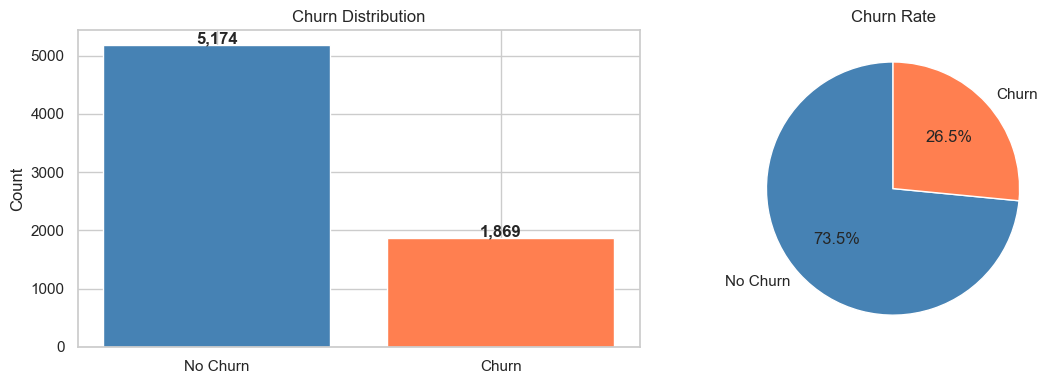

Churn rate: 26.5%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
vc = df[churn_col].value_counts()
axes[0].bar(['No Churn', 'Churn'], [vc.get(0, 0), vc.get(1, 0)],
            color=['steelblue', 'coral'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Percentage
pcts = [vc.get(0, 0) / len(df) * 100, vc.get(1, 0) / len(df) * 100]
axes[1].pie(pcts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.show()
print(f'Churn rate: {df[churn_col].mean():.1%}')

---
## 4. Feature Distributions
### Numeric Features

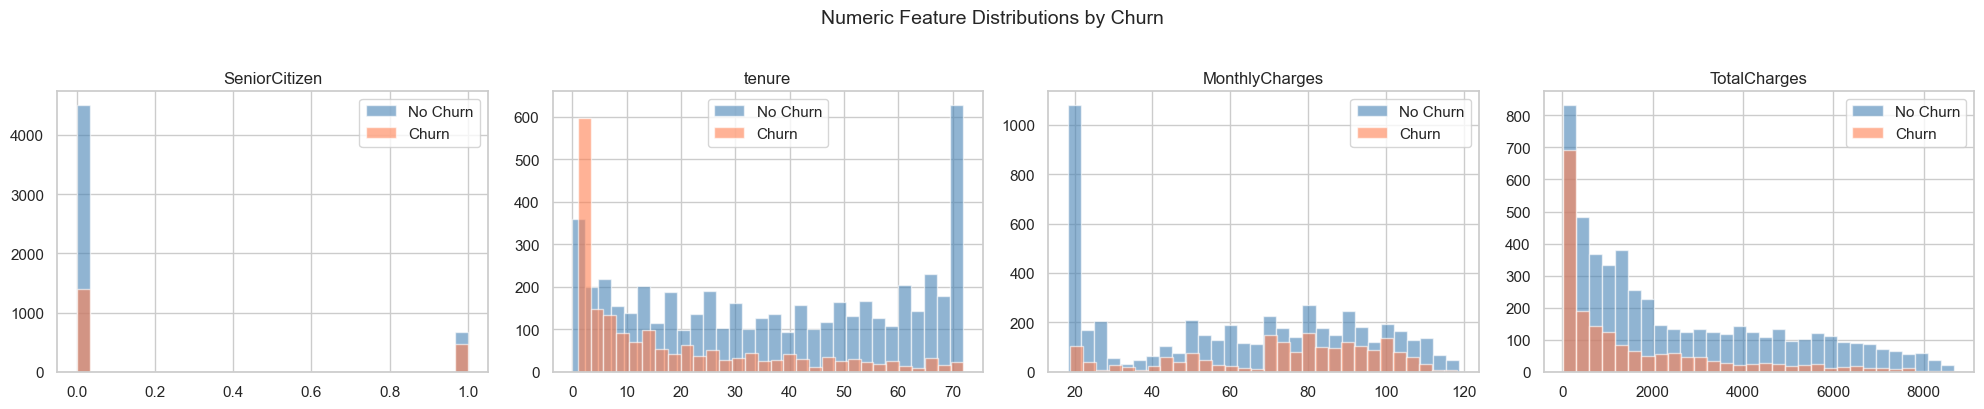

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(churn_col, errors='ignore').tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    for label, color in [(0, 'steelblue'), (1, 'coral')]:
        axes[i].hist(df[df[churn_col] == label][col].dropna(), bins=30,
                     alpha=0.6, label='Churn' if label == 1 else 'No Churn', color=color)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Categorical Features

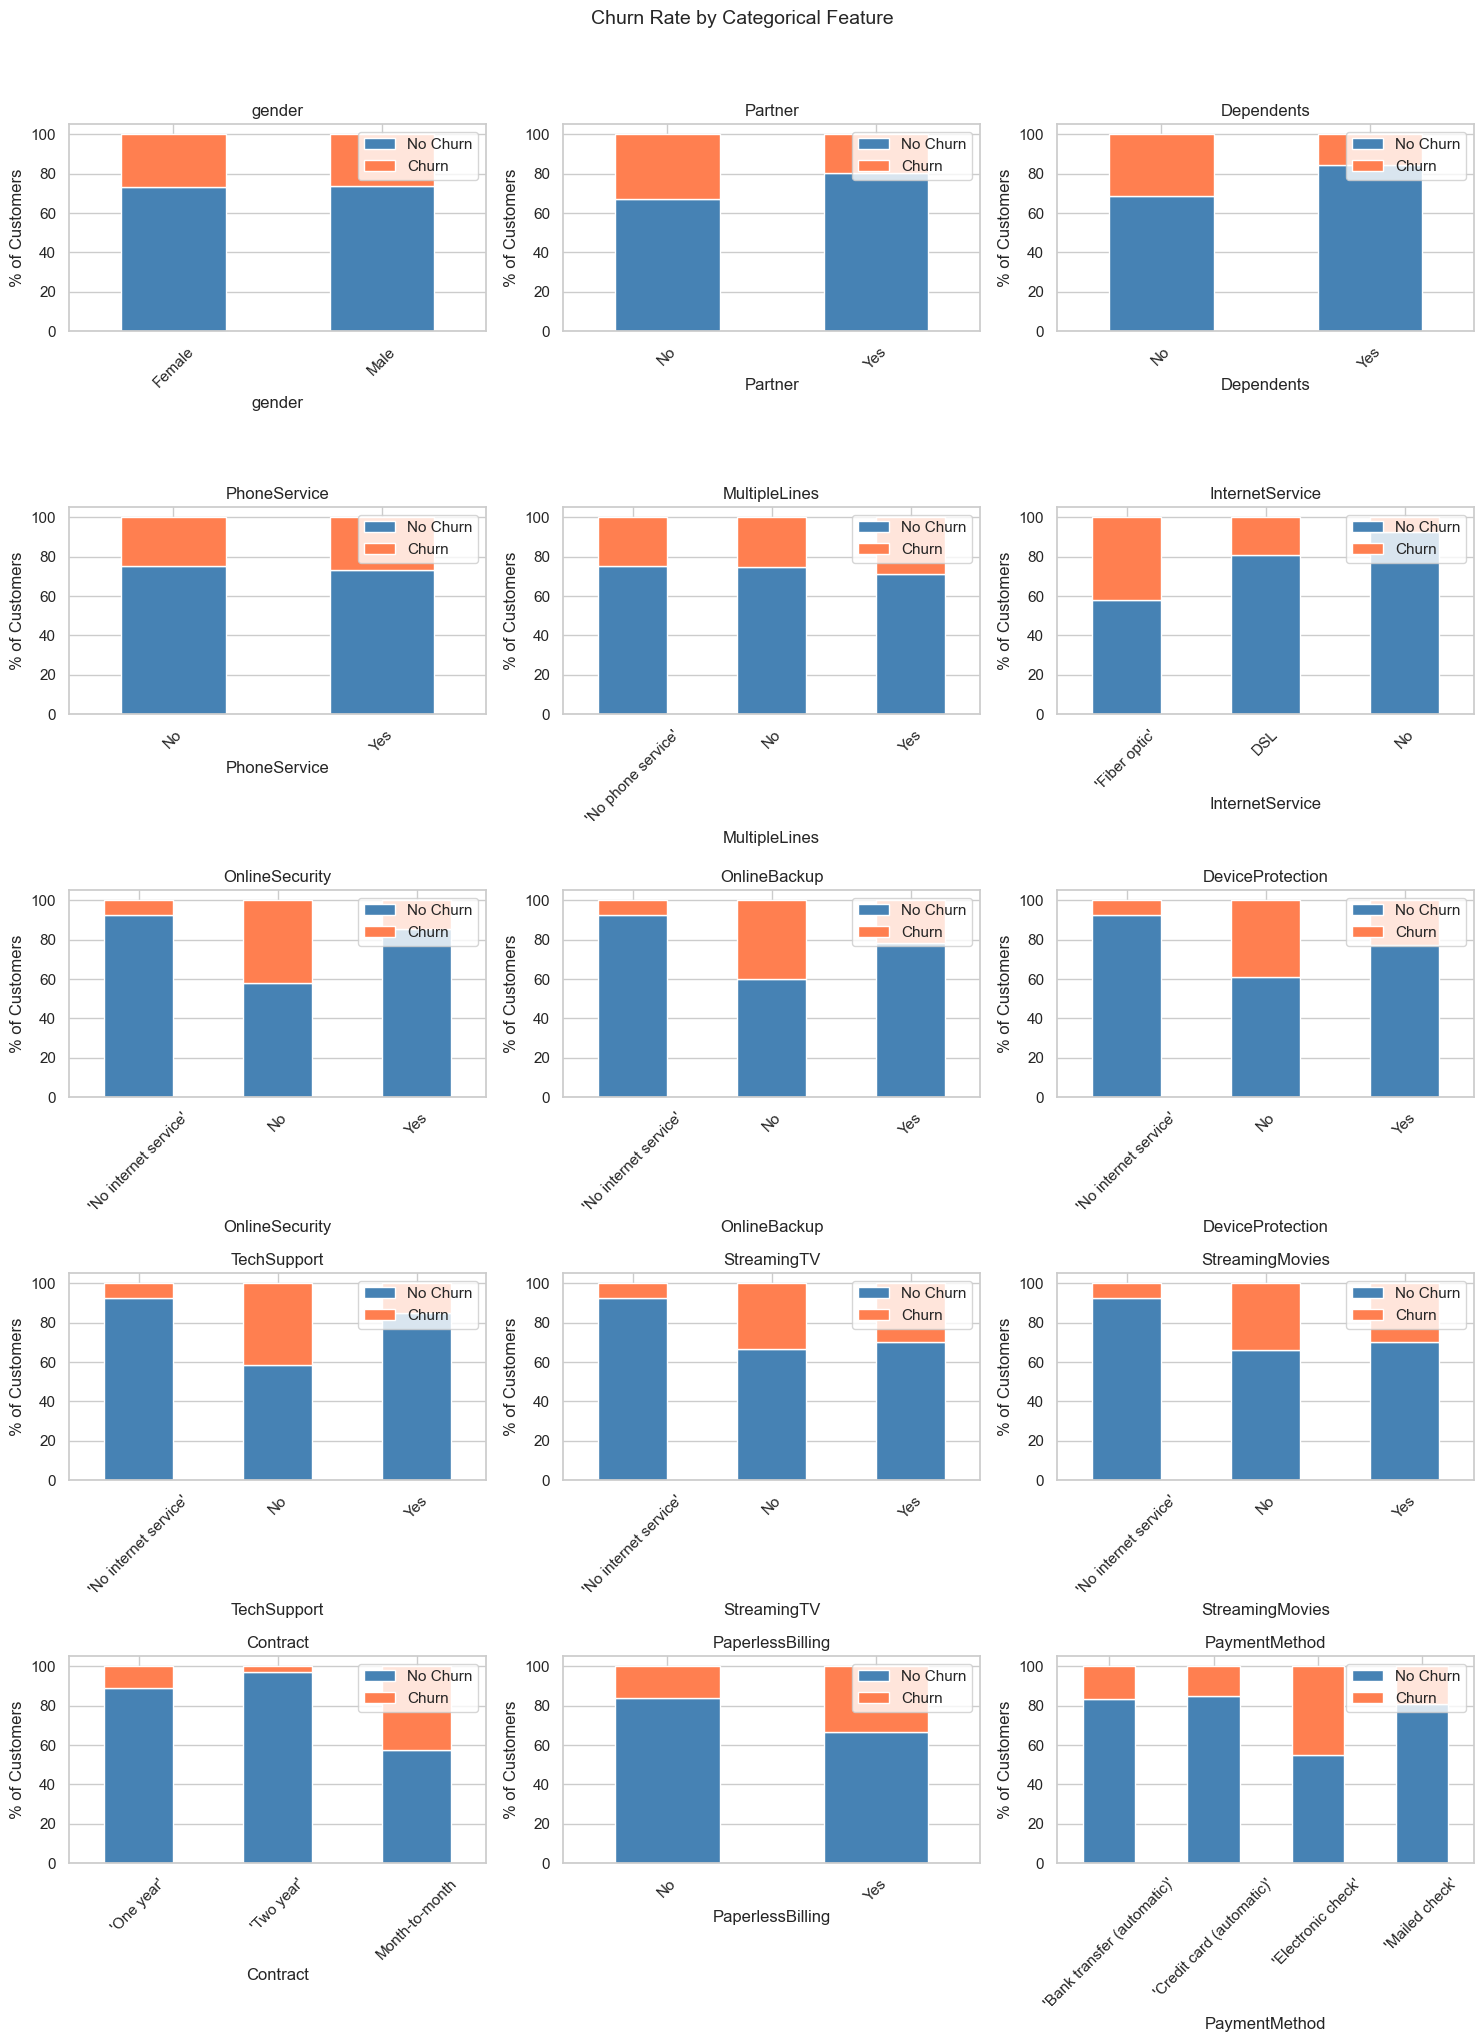

In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Remove customerID if present
cat_cols = [c for c in cat_cols if 'customerid' not in c.lower()]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df[churn_col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['steelblue', 'coral'])
    axes[i].set_title(col)
    axes[i].set_ylabel('% of Customers')
    axes[i].legend(['No Churn', 'Churn'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Correlation Analysis

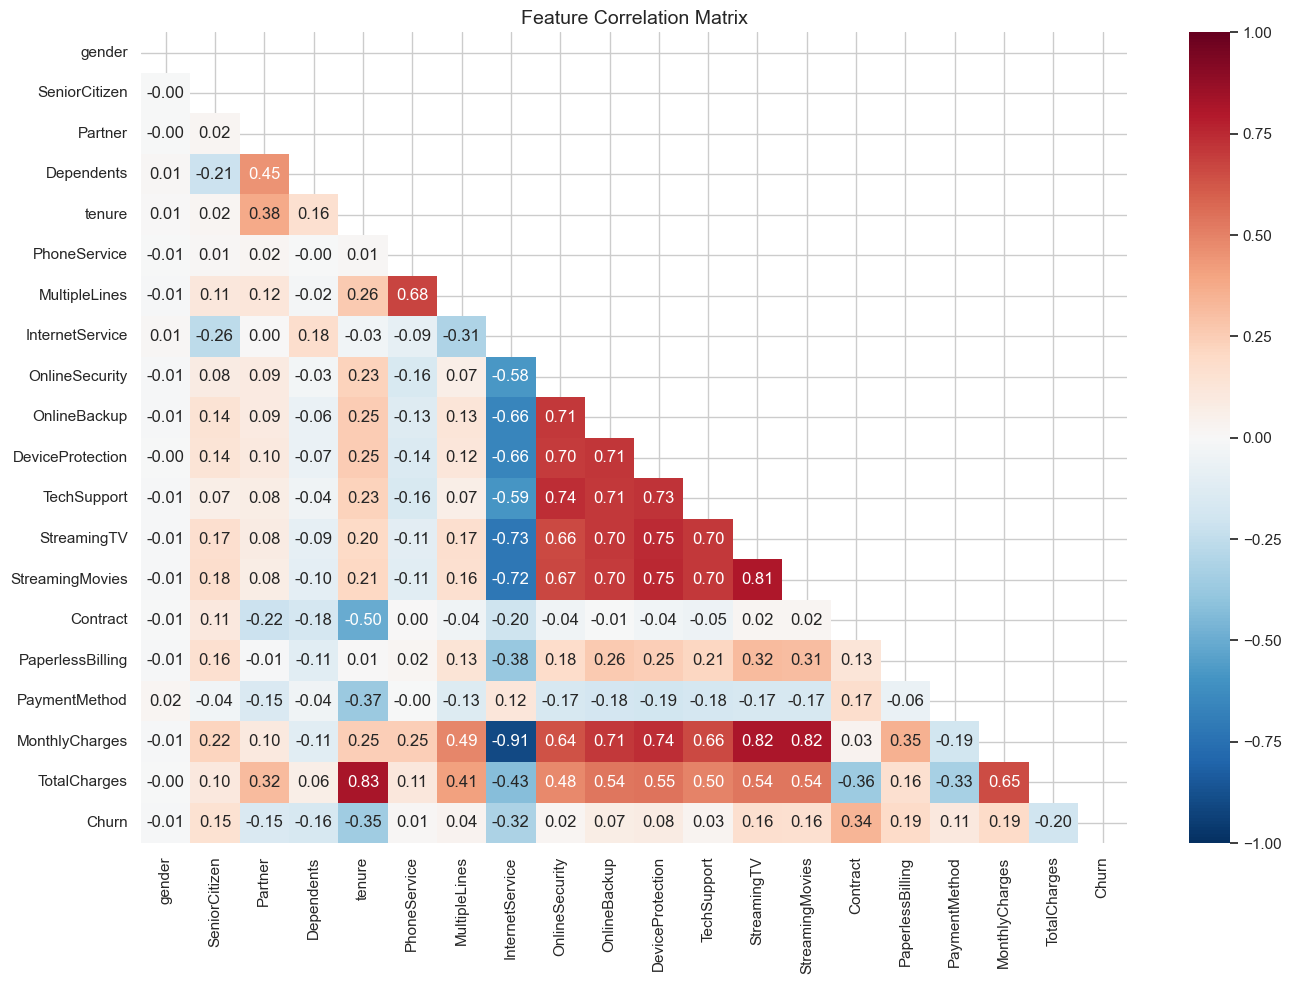

In [8]:
# Encode categoricals for correlation
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

corr = df_encoded.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Top correlations with Churn
churn_corr = corr[churn_col].drop(churn_col).sort_values(key=abs, ascending=False)
print('Top correlations with Churn:')
print(churn_corr.head(10).to_string())

Top correlations with Churn:
tenure             -0.352229
Contract            0.341504
InternetService    -0.316846
TotalCharges       -0.199037
MonthlyCharges      0.193356
PaperlessBilling    0.191825
StreamingTV         0.164673
Dependents         -0.164221
StreamingMovies     0.163220
SeniorCitizen       0.150889


---
## 6. Key Bivariate Analysis

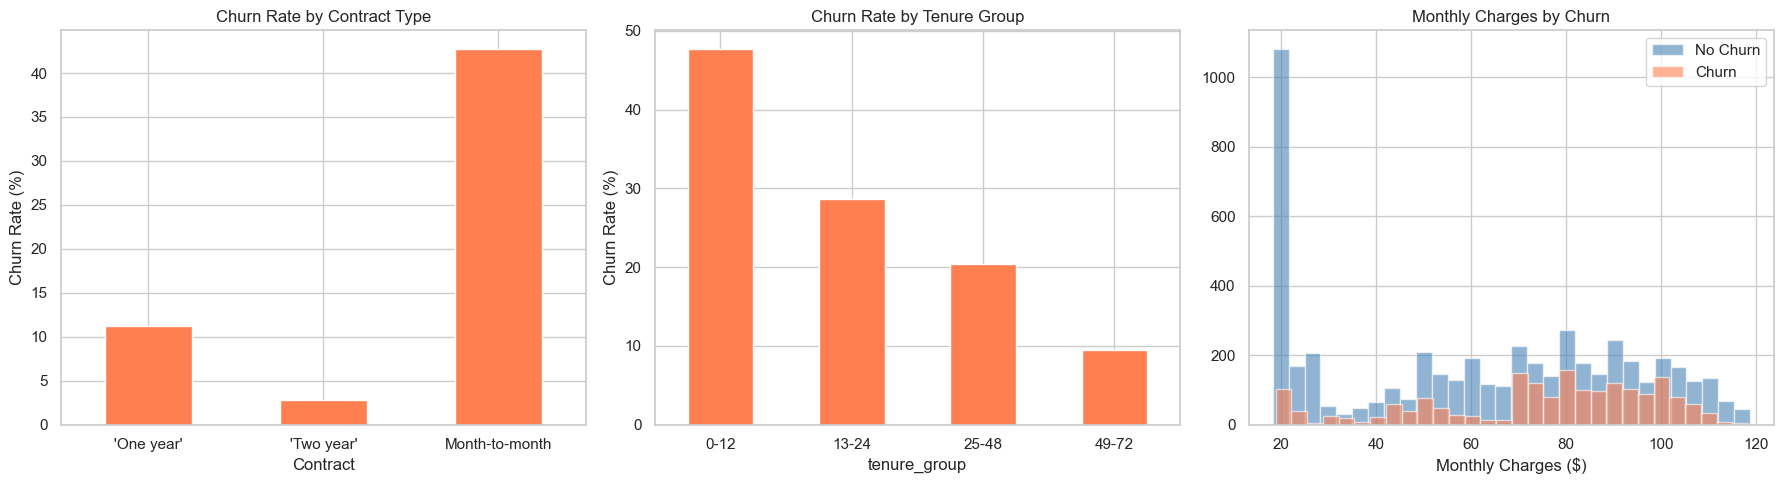

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn by Contract type
if 'Contract' in df.columns:
    ct = df.groupby('Contract')[churn_col].mean() * 100
    ct.plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Churn Rate by Contract Type')
    axes[0].set_ylabel('Churn Rate (%)')
    axes[0].tick_params(axis='x', rotation=0)

# Churn by tenure (binned)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72, 100],
                            labels=['0-12', '13-24', '25-48', '49-72', '72+'])
tenure_churn = df.groupby('tenure_group', observed=True)[churn_col].mean() * 100
tenure_churn.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

# Monthly charges vs churn
if 'MonthlyCharges' in df.columns:
    for label, color in [(0, 'steelblue'), (1, 'coral')]:
        axes[2].hist(df[df[churn_col] == label]['MonthlyCharges'],
                     bins=30, alpha=0.6, color=color,
                     label='Churn' if label == 1 else 'No Churn')
    axes[2].set_title('Monthly Charges by Churn')
    axes[2].set_xlabel('Monthly Charges ($)')
    axes[2].legend()

plt.tight_layout()
plt.show()
df.drop(columns=['tenure_group'], inplace=True)

---
## 7. Key Insights

1. **Class imbalance:** ~26% churn rate — models may need class-weight adjustment or careful metric selection (ROC-AUC over accuracy).

2. **Contract type is the strongest predictor:** Month-to-month customers churn at dramatically higher rates than those on 1- or 2-year contracts.

3. **Tenure matters:** New customers (0–12 months) churn the most. Long-tenured customers are very loyal.

4. **Higher MonthlyCharges correlate with higher churn:** Likely driven by Fiber optic internet customers who pay more but often lack bundled services.

5. **Service add-ons reduce churn:** Customers with OnlineSecurity, TechSupport, and OnlineBackup tend to stay longer.

6. **Payment method:** Electronic check users churn more — possibly due to lower commitment / ease of cancellation.

### Features to prioritise in modelling:
- `Contract`, `tenure`, `MonthlyCharges`, `InternetService`, `TotalCharges`
- Service add-ons as churn-protective indicators